In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/inventory-optimization-ml-or

/content/drive/MyDrive/inventory-optimization-ml-or


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
print("Loading processed SKU sample...")

df = pd.read_csv(
    'data/processed/sample_100_skus.csv'
)

print("Dataset Shape:", df.shape)

df.head()

Loading processed SKU sample...
Dataset Shape: (105, 1919)


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,FOODS_1_138_WI_3_validation,FOODS_1_138,FOODS_1,FOODS,WI_3,WI,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1,FOODS_1_022_CA_4_validation,FOODS_1_022,FOODS_1,FOODS,CA_4,CA,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,FOODS_1_132_WI_3_validation,FOODS_1_132,FOODS_1,FOODS,WI_3,WI,0,0,0,0,...,0,1,0,1,0,0,0,0,0,1
3,FOODS_1_035_TX_2_validation,FOODS_1_035,FOODS_1,FOODS,TX_2,TX,0,0,1,0,...,0,0,0,0,1,0,1,0,0,0
4,FOODS_1_143_CA_4_validation,FOODS_1_143,FOODS_1,FOODS,CA_4,CA,4,3,1,0,...,0,1,0,2,2,2,0,0,2,1


In [5]:
df.shape

(105, 1919)

In [6]:
metadata_cols = [
    'id',
    'item_id',
    'dept_id',
    'cat_id',
    'store_id',
    'state_id'
]

ts_cols = [
    col for col in df.columns
    if col.startswith('d_')
]

print("Metadata Columns:", len(metadata_cols))

print("Demand Columns:", len(ts_cols))

Metadata Columns: 6
Demand Columns: 1913


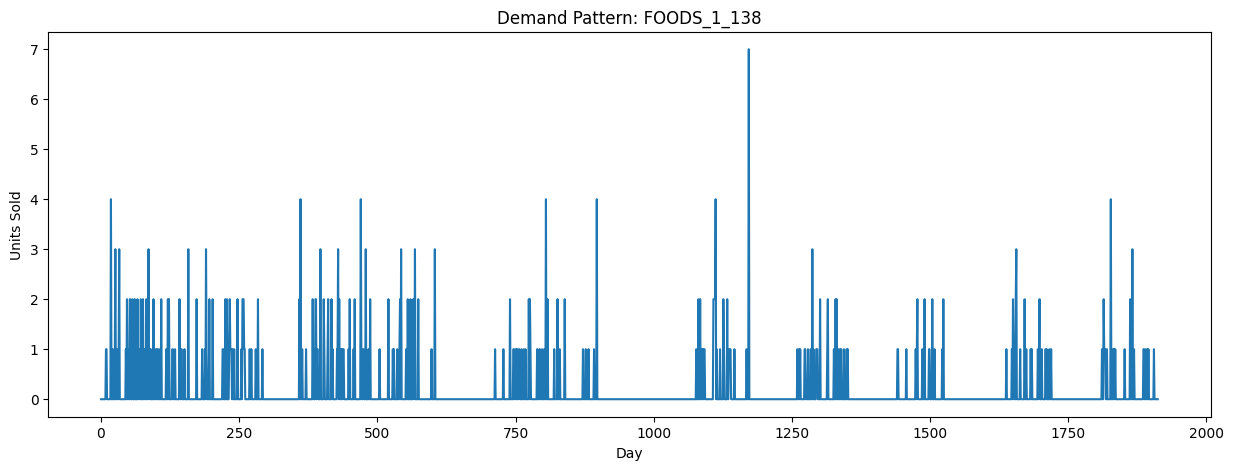

In [7]:
sku = df.iloc[0]

sales_values = sku[ts_cols].values

plt.figure(figsize=(15,5))

plt.plot(sales_values)

plt.title(f"Demand Pattern: {sku['item_id']}")

plt.xlabel("Day")

plt.ylabel("Units Sold")

plt.show()

### Observations from Demand Pattern Visualization

- The SKU exhibits highly intermittent demand behavior with long periods of zero sales followed by sudden spikes in demand.

- Demand occurrences are irregular and sparse, indicating that the product is not sold consistently on a daily basis.

- Several sharp spikes in sales are observed, suggesting bursty and volatile customer purchasing behavior.

- The demand pattern does not follow a smooth trend or stable seasonal structure, indicating non-Gaussian and highly stochastic demand characteristics.

- The presence of prolonged zero-demand intervals combined with sudden positive demand events suggests that traditional deterministic inventory models may perform poorly for such SKUs.

- This observation motivates the need for uncertainty-aware forecasting and probabilistic inventory optimization approaches instead of classical average-based inventory policies.

In [8]:
# Average demand
df['avg_demand'] = df[ts_cols].mean(axis=1)

# Standard deviation
df['std_demand'] = df[ts_cols].std(axis=1)

# Fraction of days with zero sales
df['zero_demand_ratio'] = (
    (df[ts_cols] == 0)
    .mean(axis=1)
)

# Coefficient of Variation
df['cv'] = (
    df['std_demand'] /
    (df['avg_demand'] + 1e-5)
)

display(
    df[
        [
            'item_id',
            'dept_id',
            'avg_demand',
            'std_demand',
            'cv',
            'zero_demand_ratio'
        ]
    ].head()
)

,item_id,dept_id,avg_demand,std_demand,cv,zero_demand_ratio
0,FOODS_1_138,FOODS_1,0.201777,0.586687,2.907453,0.863565
1,FOODS_1_022,FOODS_1,0.095661,0.398411,4.164373,0.928385
2,FOODS_1_132,FOODS_1,0.648197,1.265539,1.952369,0.691061
3,FOODS_1_035,FOODS_1,0.310507,1.069636,3.444693,0.836905
4,FOODS_1_143,FOODS_1,0.691584,1.421965,2.056069,0.636174


### Observations from Demand Statistics

- The sampled SKUs exhibit extremely low average daily demand, indicating infrequent purchasing activity for many products.

- The Coefficient of Variation (CV) values are significantly greater than 1 for most SKUs, demonstrating highly unstable and volatile demand behavior.

- Several SKUs show very high zero-demand ratios (60%–90%), meaning that sales occur only on a small fraction of total observed days.

- The coexistence of low average demand and high variance suggests the presence of intermittent and bursty retail demand patterns.

- Such demand characteristics violate the assumptions of traditional Gaussian-based inventory models and motivate the use of uncertainty-aware forecasting and stochastic inventory optimization techniques.

- These findings justify the need for advanced probabilistic forecasting approaches instead of deterministic average-based inventory policies.

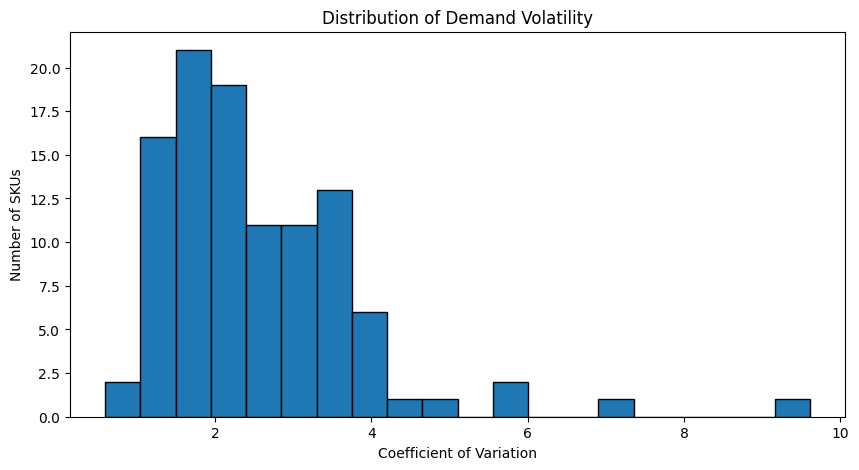

In [9]:
plt.figure(figsize=(10,5))

plt.hist(
    df['cv'],
    bins=20,
    edgecolor='black'
)

plt.title(
    'Distribution of Demand Volatility'
)

plt.xlabel('Coefficient of Variation')

plt.ylabel('Number of SKUs')

plt.show()

### Observations from CV Distribution Histogram

- The majority of sampled SKUs exhibit Coefficient of Variation (CV) values significantly greater than 1, indicating highly volatile and unstable demand behavior.

- Very few SKUs fall within the low-volatility region (CV < 0.5), suggesting that smooth and stable demand patterns are rare within the sampled retail products.

- The distribution is strongly right-skewed, with several SKUs displaying extremely high CV values, representing highly erratic and bursty demand patterns.

- Such high-volatility demand violates the assumptions of traditional Gaussian-based inventory models and deterministic safety stock formulations.

- The observed demand instability motivates the use of probabilistic forecasting, uncertainty quantification, and stochastic inventory optimization approaches in subsequent phases of the project.

In [10]:
print("Transforming to long format...")

df_long = pd.melt(
    df,
    id_vars=metadata_cols + [
        'avg_demand',
        'std_demand',
        'cv',
        'zero_demand_ratio'
    ],
    value_vars=ts_cols,
    var_name='d',
    value_name='sales'
)

Transforming to long format...


In [11]:
df_long['day'] = (
    df_long['d']
    .str.replace('d_', '')
    .astype(int)
)

df_long = df_long.drop(
    'd',
    axis=1
)

df_long = df_long.sort_values(
    ['id', 'day']
).reset_index(drop=True)

print(df_long.shape)

df_long.head()

(200865, 12)


,id,item_id,dept_id,cat_id,store_id,state_id,avg_demand,std_demand,cv,zero_demand_ratio,sales,day
0,FOODS_1_022_CA_4_validation,FOODS_1_022,FOODS_1,FOODS,CA_4,CA,0.095661,0.398411,4.164373,0.928385,0,1
1,FOODS_1_022_CA_4_validation,FOODS_1_022,FOODS_1,FOODS,CA_4,CA,0.095661,0.398411,4.164373,0.928385,0,2
2,FOODS_1_022_CA_4_validation,FOODS_1_022,FOODS_1,FOODS,CA_4,CA,0.095661,0.398411,4.164373,0.928385,0,3
3,FOODS_1_022_CA_4_validation,FOODS_1_022,FOODS_1,FOODS,CA_4,CA,0.095661,0.398411,4.164373,0.928385,0,4
4,FOODS_1_022_CA_4_validation,FOODS_1_022,FOODS_1,FOODS,CA_4,CA,0.095661,0.398411,4.164373,0.928385,0,5


### Observation: Wide-to-Long Transformation

The original M5 sales data was converted from wide format, where each SKU had 1913 separate daily sales columns, into long format, where each row represents one SKU-day observation.

This transformation creates a machine-learning-ready panel dataset. SKU-level statistical features such as average demand, demand volatility, coefficient of variation, and zero-demand ratio are repeated across daily observations for each SKU, while the `sales` column captures the actual demand on each day.

This structure is essential for future feature engineering steps such as lag variables, rolling statistics, temporal train-test splitting, and demand forecasting models.

In [12]:
df_long.to_csv(
    'data/processed/sample_100_skus_long.csv',
    index=False
)

print("Long-format dataset saved successfully.")

Long-format dataset saved successfully.


In [13]:
def calculate_adi(row):

    sales = row[ts_cols].values

    non_zero_days = np.where(
        sales > 0
    )[0]

    if len(non_zero_days) <= 1:
        return np.nan

    intervals = np.diff(non_zero_days)

    return np.mean(intervals)

df['adi'] = df.apply(
    calculate_adi,
    axis=1
)

In [14]:
df['cv_squared'] = (
    df['cv'] ** 2
)

In [15]:
def classify_demand(row):

    if row['adi'] < 1.32 and row['cv_squared'] < 0.49:
        return 'Smooth'

    elif row['adi'] < 1.32 and row['cv_squared'] >= 0.49:
        return 'Erratic'

    elif row['adi'] >= 1.32 and row['cv_squared'] < 0.49:
        return 'Intermittent'

    else:
        return 'Lumpy'

df['demand_type'] = df.apply(
    classify_demand,
    axis=1
)

df['demand_type'].value_counts()

,count
demand_type,
Lumpy,99
Erratic,5
Smooth,1


### Observations from SBA Demand Classification

The SBA-based demand classification shows that the sampled SKU set is dominated by lumpy demand behavior. Out of 105 sampled SKUs, 99 are classified as Lumpy, 5 as Erratic, and only 1 as Smooth.

This indicates that most products exhibit both infrequent demand occurrence and high variability in demand size. Such demand patterns are difficult to model using traditional deterministic forecasting methods or Gaussian-based safety stock formulas.

The dominance of lumpy and erratic SKUs provides strong empirical motivation for uncertainty-aware forecasting methods, such as conformal prediction, and stochastic inventory optimization approaches. This result supports the core research premise that retail inventory decisions should account for both demand intermittency and demand volatility.

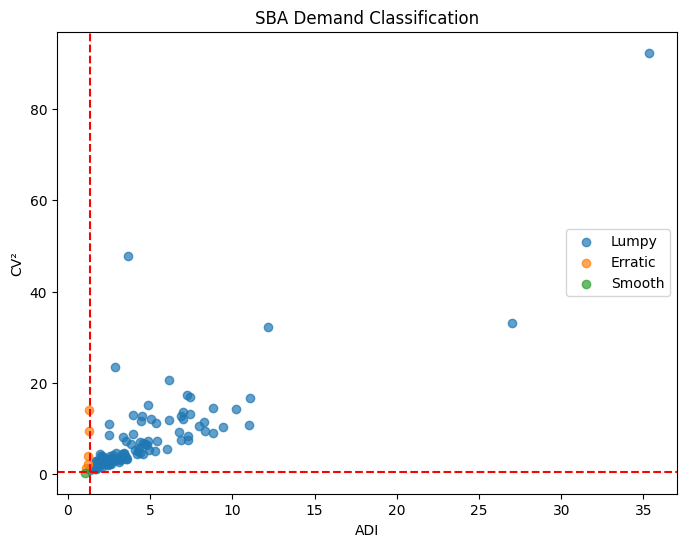

In [16]:
plt.figure(figsize=(8,6))

for demand_type in df['demand_type'].unique():

    subset = df[
        df['demand_type'] == demand_type
    ]

    plt.scatter(
        subset['adi'],
        subset['cv_squared'],
        label=demand_type,
        alpha=0.7
    )

plt.axvline(
    1.32,
    color='red',
    linestyle='--'
)

plt.axhline(
    0.49,
    color='red',
    linestyle='--'
)

plt.xlabel('ADI')

plt.ylabel('CV²')

plt.title('SBA Demand Classification')

plt.legend()

plt.show()

### Observations from SBA Demand Classification Plot

- The majority of sampled SKUs are concentrated in the upper-right quadrant of the SBA classification space, corresponding to Lumpy demand behavior.

- These SKUs exhibit both high Average Demand Interval (ADI) and high demand variability (CV²), indicating sparse and highly volatile demand patterns.

- Only a very small number of SKUs fall into the Smooth or Erratic demand regions, suggesting that stable retail demand is uncommon within the sampled dataset.

- Several extreme outliers are observed with exceptionally high ADI and CV² values, representing highly intermittent and operationally challenging products.

- The dominance of lumpy demand highlights the limitations of traditional deterministic forecasting and inventory control methods.

- These findings strongly motivate the use of uncertainty-aware forecasting, probabilistic inventory policies, and stochastic optimization frameworks for retail inventory management.

In [17]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	kaggle (1).json

nothing added to commit but untracked files present (use "git add" to track)


In [18]:
%%writefile .gitignore

# Data and Models
data/
*.csv
*.pkl
*.pt
*.h5

# Kaggle credentials
kaggle*.json

# Python and Jupyter
__pycache__/
*.pyc
.ipynb_checkpoints/
mlruns/
.env

Overwriting .gitignore


In [19]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   .gitignore

no changes added to commit (use "git add" and/or "git commit -a")


In [20]:
!git add .

!git commit -m "Phase 1: Demand volatility analysis and SBA demand classification"

!git push origin main

Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@b24d8a70afec.(none)')
Everything up-to-date


In [21]:
!git config --global user.email "smrititubid@gmail.com"

!git config --global user.name "smrititubid-afk"

In [22]:
!git add .

!git commit -m "Phase 1: Demand volatility analysis and SBA demand classification"

!git push origin main

[main c9c8040] Phase 1: Demand volatility analysis and SBA demand classification
 1 file changed, 5 insertions(+), 14 deletions(-)
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 483 bytes | 48.00 KiB/s, done.
Total 3 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/smrititubid-afk/inventory-optimization-ml-or.git
   b568e48..c9c8040  main -> main


In [23]:
!ls

 data		    notebooks   README.md   requirements.txt
'kaggle (1).json'   outputs     reports     src


In [24]:
!rm "kaggle (1).json"

In [26]:
!find . -name "*.ipynb"